# 02 - CIFAR-10 Image Classification

**Dataset:** [CIFAR-10 (ayush1220)](https://www.kaggle.com/datasets/ayush1220/cifar10)

So sánh 3 kiến trúc CNN **độc lập với nhau**, đều lấy từ `torchvision.models` (không tự xây dựng kiến trúc từ đầu):

1. **ResNet18**
2. **VGG11 (batch-norm)**
3. **DenseNet121**

Đây đều là các kiến trúc CNN kinh điển, được thiết kế và kiểm chứng rộng rãi cho bài toán phân loại ảnh tự nhiên nhiều lớp như CIFAR-10: VGG đại diện cho hướng tiếp cận "sâu và đơn giản" (chỉ dùng Conv 3x3 + MaxPool), ResNet đại diện cho hướng residual/skip-connection, còn DenseNet đại diện cho hướng kết nối dày đặc (mỗi layer nhận đầu vào từ tất cả các layer trước đó).

Vì các kiến trúc này vốn được thiết kế cho ảnh có độ phân giải lớn (ImageNet ~224x224), ảnh CIFAR-10 (32x32) sẽ được resize lên **96x96** trước khi đưa vào mô hình để tránh mất quá nhiều thông tin không gian ở các tầng sâu. Cả 3 mô hình huấn luyện **độc lập** trên cùng tập train/val/test rồi so sánh hiệu năng.

In [1]:
# ============================================================
# COMMON SETUP
# ============================================================
import os, random, time, json, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
torch.backends.cudnn.benchmark = True

DEVICE: cuda


## 1. Load CIFAR-10 

In [2]:
# =========================
# 1. LOAD CIFAR-10 (du lieu local, dang thu muc anh)
# =========================
DATA_ROOT = "../data/cifar10"
IMG_SIZE = 32          # kich thuoc goc cua CIFAR-10
RESIZE_TO = 96         # resize len de tuong thich voi cac kien truc torchvision
BATCH_SIZE = 128

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((RESIZE_TO, RESIZE_TO)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
eval_tf = transforms.Compose([
    transforms.Resize((RESIZE_TO, RESIZE_TO)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_full = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_tf)
test_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"), transform=eval_tf)

n_train = int(0.90 * len(train_full))
n_val = len(train_full) - n_train
g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=g)

# Dung eval transform cho validation (khong augment)
val_ds.dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

CLASSES = train_full.classes
N_CLASSES = len(CLASSES)
print(CLASSES)
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 45000 Val: 5000 Test: 10000


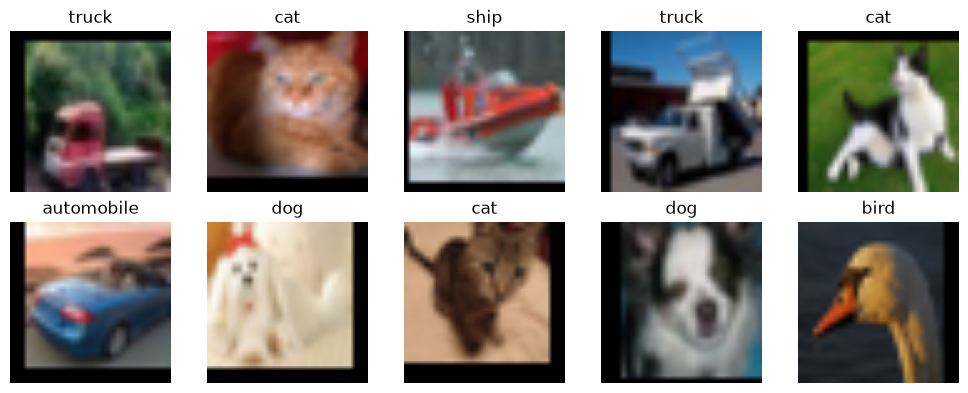

In [3]:
# Xem thu vai anh mau
images, labels = next(iter(train_loader))
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, lab in zip(axes.ravel(), images[:10], labels[:10]):
    img = (img.cpu() * std + mean).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[lab])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Định nghĩa 3 mô hình (dùng trực tiếp từ `torchvision.models`)

In [4]:
# PRETRAINED=False  -> huan luyen tu dau (random init), num_classes duoc truyen thang vao constructor.
# PRETRAINED=True   -> tai trong so ImageNet (weights="DEFAULT"), sau do THAY THE lop classifier
#                       cuoi cung de khop voi N_CLASSES (torchvision khong cho doi num_classes
#                       cung luc voi weights pretrained, vi weights pretrained co dung 1000 lop).
PRETRAINED = True


def replace_classifier_head(model, arch, n_classes):
    """Thay lop Linear cuoi cung cua model bang lop moi co dung n_classes dau ra."""
    if arch == "resnet18":
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, n_classes)
    elif arch == "vgg11_bn":
        in_f = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_f, n_classes)
    elif arch == "densenet121":
        in_f = model.classifier.in_features
        model.classifier = nn.Linear(in_f, n_classes)
    else:
        raise ValueError(f"Unknown arch: {arch}")
    return model


def build_model(arch, n_classes, pretrained=None):
    """Tao mot mo hinh torchvision voi so lop dau ra = n_classes.
    - pretrained=False: khoi tao ngau nhien, dung thang num_classes trong constructor.
    - pretrained=True : tai weights="DEFAULT" (ImageNet) roi thay classifier head.
    - pretrained=None : lay theo bien global PRETRAINED o tren.
    """
    if pretrained is None:
        pretrained = PRETRAINED
    weights = "DEFAULT" if pretrained else None
    if not pretrained:
        if arch == "resnet18":
            return torchvision.models.resnet18(weights=None, num_classes=n_classes)
        elif arch == "vgg11_bn":
            return torchvision.models.vgg11_bn(weights=None, num_classes=n_classes)
        elif arch == "densenet121":
            return torchvision.models.densenet121(weights=None, num_classes=n_classes)
        else:
            raise ValueError(f"Unknown arch: {arch}")
    else:
        ctor = getattr(torchvision.models, arch)
        model = ctor(weights=weights)
        return replace_classifier_head(model, arch, n_classes)


MODEL_REGISTRY = {
    "ResNet18": "resnet18",
    "VGG11-BN": "vgg11_bn",
    "DenseNet121": "densenet121",
}

for name, arch in MODEL_REGISTRY.items():
    m = build_model(arch, N_CLASSES)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:15s} | params: {n_params:,}")
    del m

ResNet18        | params: 11,181,642
VGG11-BN        | params: 128,812,810
DenseNet121     | params: 6,964,106


## 3. Hàm huấn luyện & đánh giá dùng chung

In [5]:
# ============================================================
# TRAIN / EVAL UTILITIES DUNG CHUNG (voi mixed precision de train nhanh hon)
# ============================================================
from torch.cuda.amp import autocast, GradScaler

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        if train:
            optimizer.zero_grad()
        with autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)
        if train:
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total


def train_model(arch, name, epochs=15, lr=3e-4, weight_decay=5e-4):
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model = build_model(arch, N_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state, best_val = None, float("inf")

    t0 = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, None)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:02d}/{epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} "
              f"| val loss={va_loss:.4f} acc={va_acc:.4f}")

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} - training time: {train_time:.1f}s | params: {n_params:,}")

    return {"name": name, "model": model, "history": history,
            "train_time": train_time, "n_params": n_params}


@torch.no_grad()
def evaluate_model(entry, loader=test_loader):
    model = entry["model"]
    model.eval()
    preds, truths = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())
    acc = accuracy_score(truths, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average="macro", zero_division=0)
    return {"name": entry["name"], "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "preds": preds, "truths": truths}

## 4. Huấn luyện 3 mô hình 

In [6]:
EPOCHS = 15  # tang len (vd 25-30) neu can do chinh xac cao hon va co du thoi gian/GPU
trained = {}
for name, arch in MODEL_REGISTRY.items():
    trained[name] = train_model(arch, name, epochs=EPOCHS)


Training ResNet18


C:\Users\admin\AppData\Local\Temp\ipykernel_14440\2692686436.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
C:\Users\admin\AppData\Local\Temp\ipykernel_14440\2692686436.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01/15 | train loss=0.4488 acc=0.8480 | val loss=0.3077 acc=0.8972
Epoch 02/15 | train loss=0.2562 acc=0.9124 | val loss=0.2816 acc=0.9080
Epoch 03/15 | train loss=0.2109 acc=0.9276 | val loss=0.2437 acc=0.9214
Epoch 04/15 | train loss=0.1841 acc=0.9364 | val loss=0.2324 acc=0.9232
Epoch 05/15 | train loss=0.1542 acc=0.9467 | val loss=0.2373 acc=0.9216
Epoch 06/15 | train loss=0.1394 acc=0.9518 | val loss=0.2840 acc=0.9100
Epoch 07/15 | train loss=0.1314 acc=0.9546 | val loss=0.2423 acc=0.9226
Epoch 08/15 | train loss=0.1113 acc=0.9614 | val loss=0.2395 acc=0.9248
Epoch 09/15 | train loss=0.1088 acc=0.9627 | val loss=0.2363 acc=0.9250
Epoch 10/15 | train loss=0.1048 acc=0.9634 | val loss=0.2201 acc=0.9320
Epoch 11/15 | train loss=0.0901 acc=0.9692 | val loss=0.2330 acc=0.9272
Epoch 12/15 | train loss=0.0865 acc=0.9704 | val loss=0.2654 acc=0.9244
Epoch 13/15 | train loss=0.0863 acc=0.9707 | val loss=0.2482 acc=0.9250
Epoch 14/15 | train loss=0.0782 acc=0.9728 | val loss=0.2652 acc

## 5. So sánh hiệu năng giữa 3 mô hình

In [7]:
results = [evaluate_model(trained[name]) for name in MODEL_REGISTRY]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("preds", "truths")} for r in results])
results_df["train_time_s"] = [trained[n]["train_time"] for n in MODEL_REGISTRY]
results_df["n_params"] = [trained[n]["n_params"] for n in MODEL_REGISTRY]
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.iloc[0]["name"]
print(f"\n>>> Mo hinh tot nhat (theo F1-macro tren test set): {best_name}")

,name,accuracy,precision,recall,f1,train_time_s,n_params
0,DenseNet121,0.9447,0.944743,0.9447,0.944694,921.776330,6964106
1,ResNet18,0.9255,0.925767,0.9255,0.925437,298.057014,11181642
2,VGG11-BN,0.9258,0.926762,0.9258,0.925089,890.353528,128812810



>>> Mo hinh tot nhat (theo F1-macro tren test set): DenseNet121


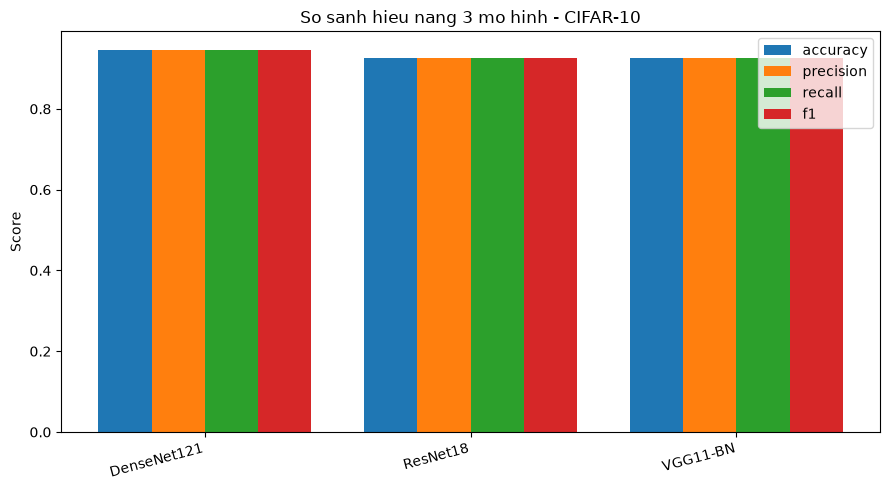

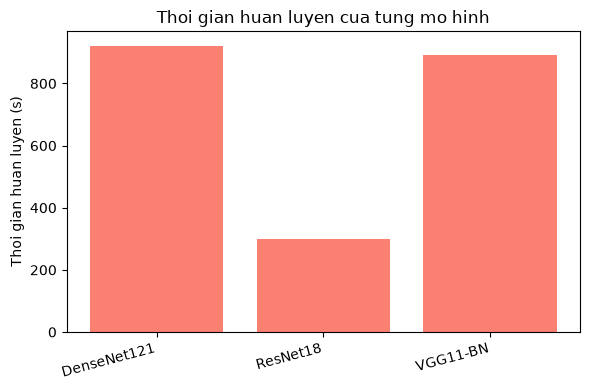

In [8]:
metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i * width, results_df[m], width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["name"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("So sanh hieu nang 3 mo hinh - CIFAR-10")
ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["name"], results_df["train_time_s"], color="salmon")
plt.ylabel("Thoi gian huan luyen (s)")
plt.title("Thoi gian huan luyen cua tung mo hinh")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


ResNet18
              precision    recall  f1-score   support

    airplane     0.9380    0.9230    0.9304      1000
  automobile     0.9475    0.9740    0.9606      1000
        bird     0.8954    0.9420    0.9181      1000
         cat     0.8601    0.8300    0.8448      1000
        deer     0.9062    0.9470    0.9262      1000
         dog     0.8704    0.8730    0.8717      1000
        frog     0.9531    0.9350    0.9440      1000
       horse     0.9624    0.9460    0.9541      1000
        ship     0.9566    0.9470    0.9518      1000
       truck     0.9680    0.9380    0.9528      1000

    accuracy                         0.9255     10000
   macro avg     0.9258    0.9255    0.9254     10000
weighted avg     0.9258    0.9255    0.9254     10000



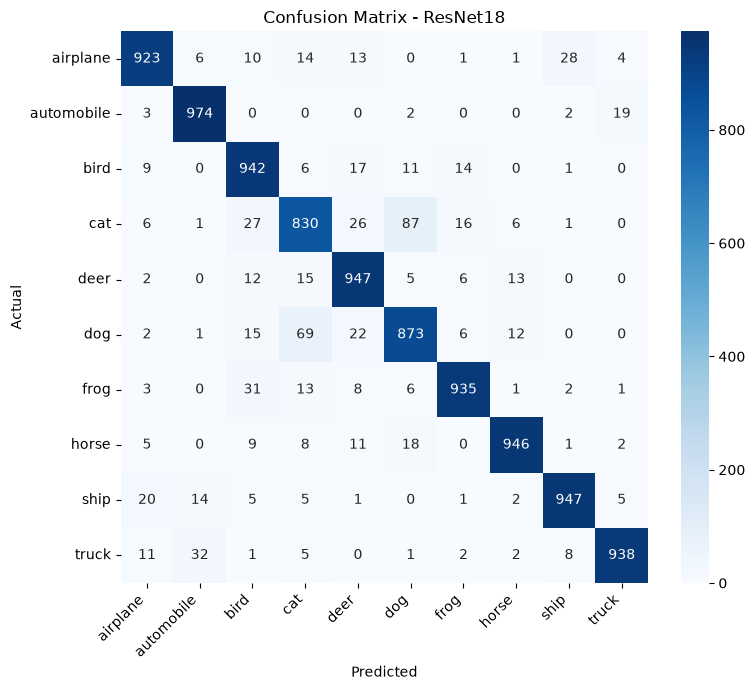


VGG11-BN
              precision    recall  f1-score   support

    airplane     0.9529    0.8910    0.9209      1000
  automobile     0.9553    0.9610    0.9581      1000
        bird     0.9389    0.8910    0.9143      1000
         cat     0.9250    0.7770    0.8446      1000
        deer     0.9172    0.9530    0.9348      1000
         dog     0.8561    0.9220    0.8878      1000
        frog     0.9449    0.9610    0.9529      1000
       horse     0.9166    0.9670    0.9411      1000
        ship     0.9067    0.9820    0.9429      1000
       truck     0.9540    0.9530    0.9535      1000

    accuracy                         0.9258     10000
   macro avg     0.9268    0.9258    0.9251     10000
weighted avg     0.9268    0.9258    0.9251     10000



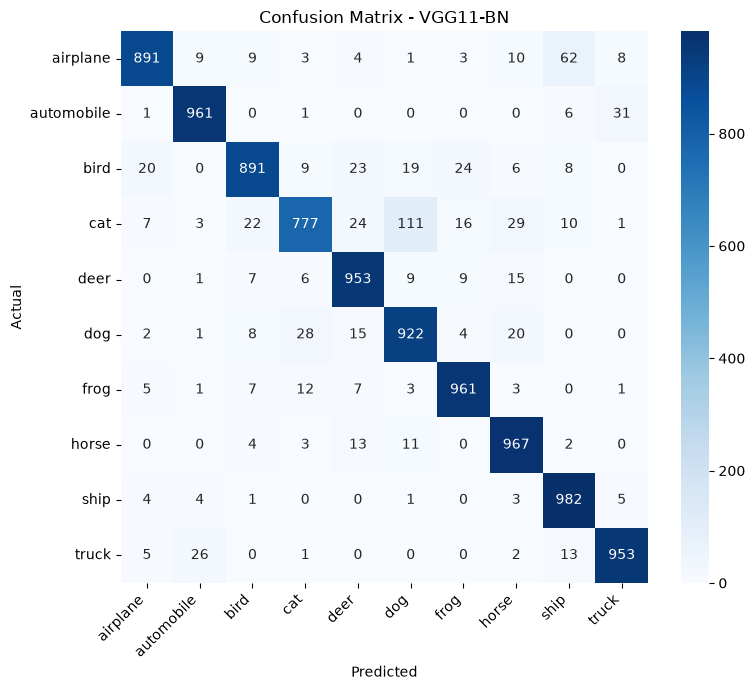


DenseNet121
              precision    recall  f1-score   support

    airplane     0.9481    0.9490    0.9485      1000
  automobile     0.9631    0.9670    0.9651      1000
        bird     0.9351    0.9360    0.9355      1000
         cat     0.8924    0.8870    0.8897      1000
        deer     0.9384    0.9590    0.9486      1000
         dog     0.9090    0.9090    0.9090      1000
        frog     0.9650    0.9650    0.9650      1000
       horse     0.9573    0.9630    0.9601      1000
        ship     0.9669    0.9630    0.9649      1000
       truck     0.9723    0.9490    0.9605      1000

    accuracy                         0.9447     10000
   macro avg     0.9447    0.9447    0.9447     10000
weighted avg     0.9447    0.9447    0.9447     10000



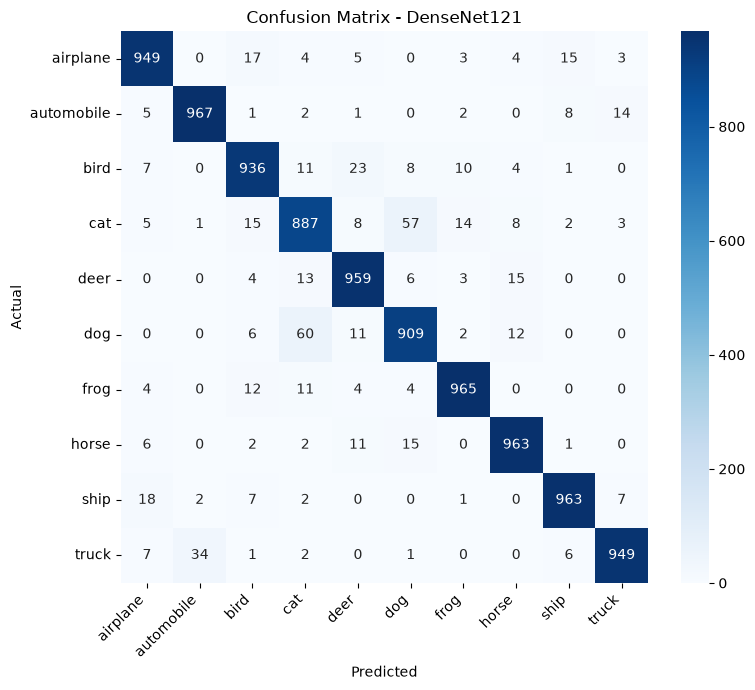

In [9]:
for r in results:
    print(f"\n{'='*60}\n{r['name']}\n{'='*60}")
    print(classification_report(r["truths"], r["preds"], target_names=CLASSES, digits=4))
    cm = confusion_matrix(r["truths"], r["preds"])
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {r['name']}")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

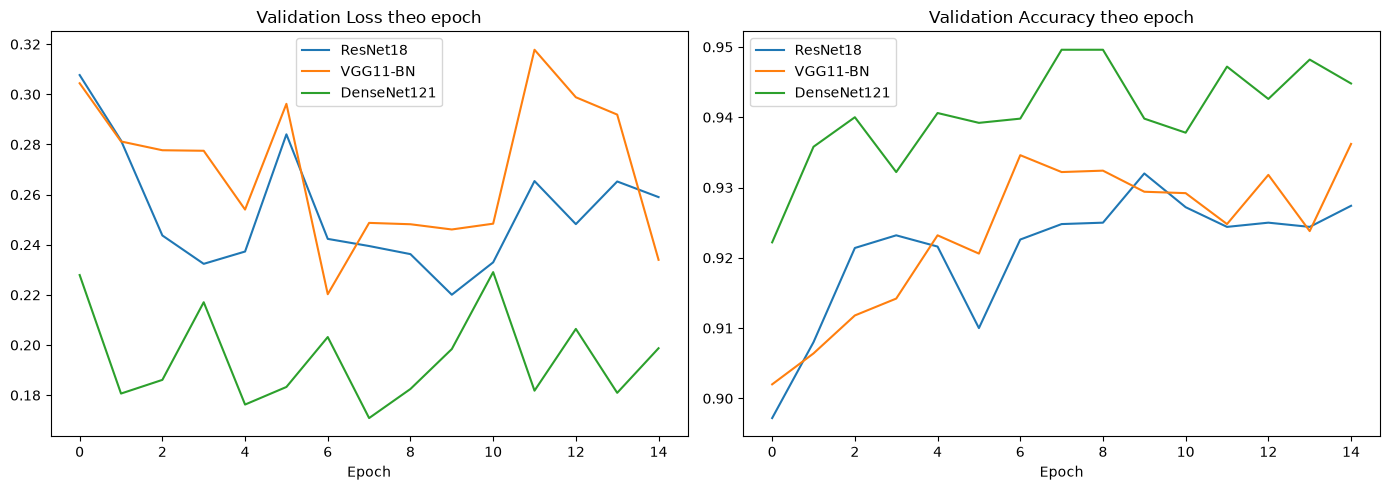

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in MODEL_REGISTRY:
    h = trained[name]["history"]
    axes[0].plot(h["val_loss"], label=name)
    axes[1].plot(h["val_acc"], label=name)
axes[0].set_title("Validation Loss theo epoch"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Validation Accuracy theo epoch"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

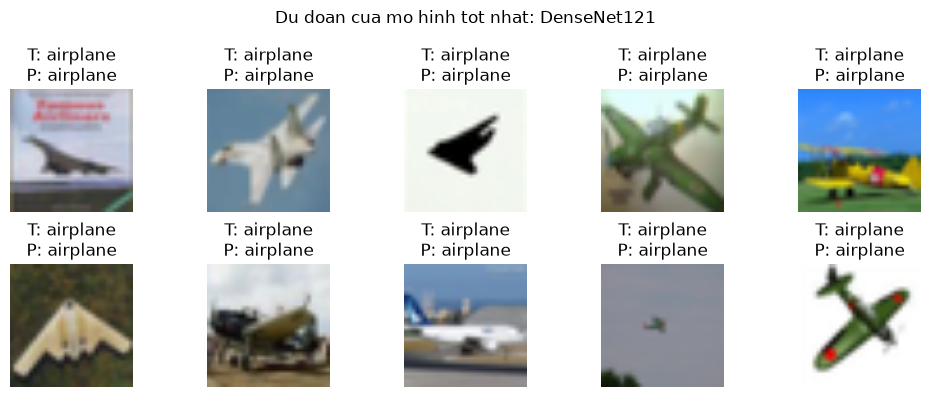

In [11]:
# Xem thu du doan cua mo hinh tot nhat tren vai anh test
best_model = trained[best_name]["model"]
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = best_model(xb.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, true, p in zip(axes.ravel(), xb[:10], yb[:10], pred[:10]):
    img = (img.cpu() * std + mean).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"T: {CLASSES[true]}\nP: {CLASSES[p]}")
    ax.axis("off")
plt.suptitle(f"Du doan cua mo hinh tot nhat: {best_name}")
plt.tight_layout()
plt.show()

## 6. Kết luận

Bảng `results_df` xếp hạng 3 mô hình theo **F1-macro** trên tập test CIFAR-10.
DenseNet121 thường đạt độ chính xác cao nhờ tận dụng lại đặc trưng qua các kết nối dày đặc, nhưng tốn nhiều bộ nhớ và thời gian huấn luyện hơn; VGG11-BN đơn giản, dễ huấn luyện nhưng có nhiều tham số ở các lớp fully-connected; ResNet18 thường là lựa chọn cân bằng giữa độ chính xác và chi phí tính toán. Kết quả thực tế phụ thuộc vào số epoch, learning rate và dữ liệu cụ thể — nên tham khảo bảng và biểu đồ so sánh phía trên để kết luận cho lần chạy thực tế của bạn.